In [2]:
%pip install numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 7.5 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 11.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 8.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


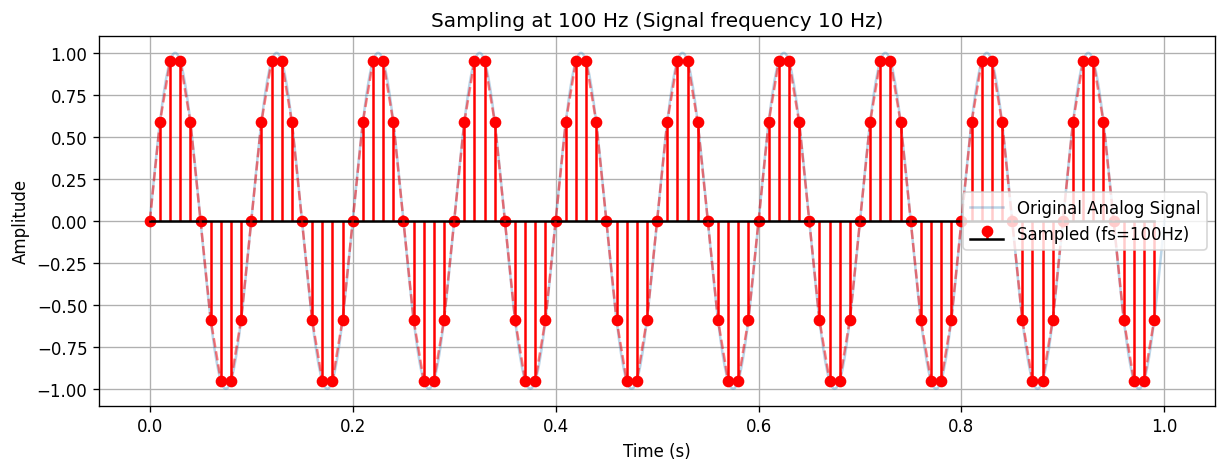

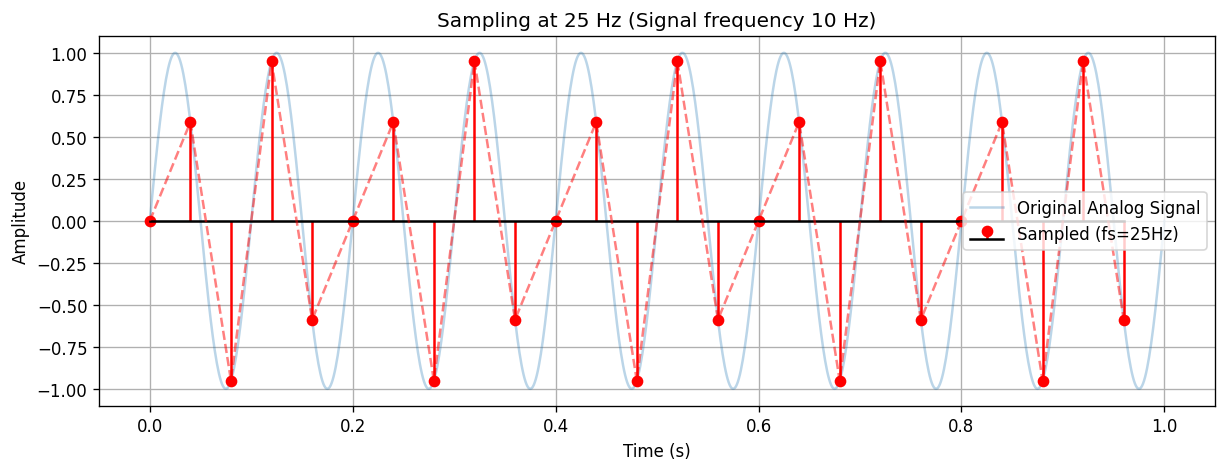

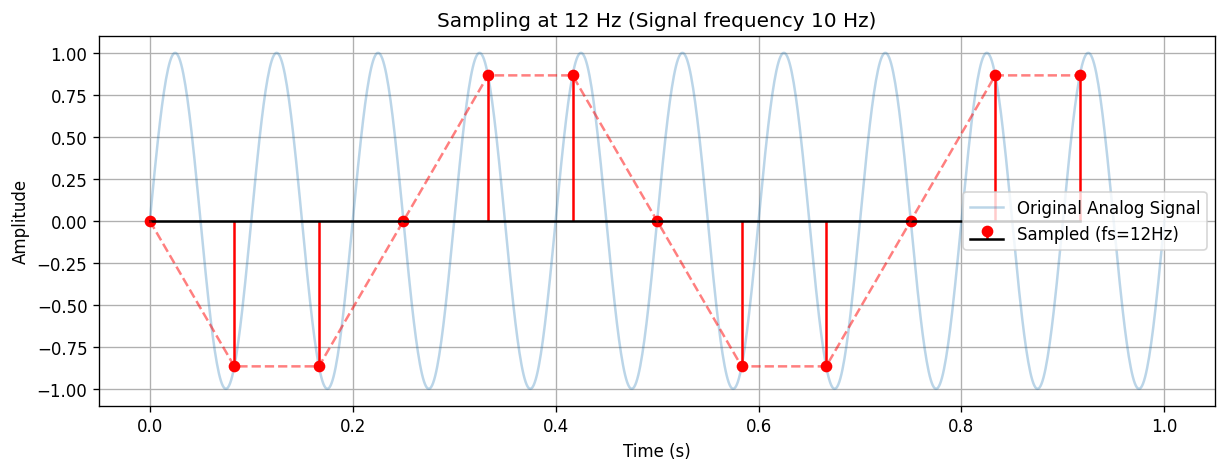

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 模拟一个“连续”的原始信号
f_signal = 10 # 信号频率为 10 Hz
t_continuous = np.linspace(0, 1, 1000) # 极高采样率模拟连续
y_continuous = np.sin(2 * np.pi * f_signal * t_continuous)

def plot_sampling(fs):
    # 2. 进行采样
    t_sampled = np.arange(0, 1, 1/fs)
    y_sampled = np.sin(2 * np.pi * f_signal * t_sampled)

    plt.figure(figsize=(12, 4))
    # 绘制背景连续波形
    plt.plot(t_continuous, y_continuous, label='Original Analog Signal', alpha=0.3)
    # 绘制采样点
    # plt.stem(t_sampled, y_sampled, 'r', label=f'Sampled (fs={fs}Hz)',
    # use_line_collection=True)
    plt.stem(t_sampled, y_sampled, linefmt='r-', markerfmt='ro', basefmt='k-', label=f'Sampled (fs={fs}Hz)')
    # 绘制重建后的波形
    plt.plot(t_sampled, y_sampled, 'r--', alpha=0.5)

    plt.title(f"Sampling at {fs} Hz (Signal frequency {f_signal} Hz)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

# 实验演示
plot_sampling(100) # 场景1：良好还原
plot_sampling(25) # 场景2：勉强还原 (满足奈奎斯特)
plot_sampling(12) # 场景3：发生混叠 (不满足奈奎斯特)

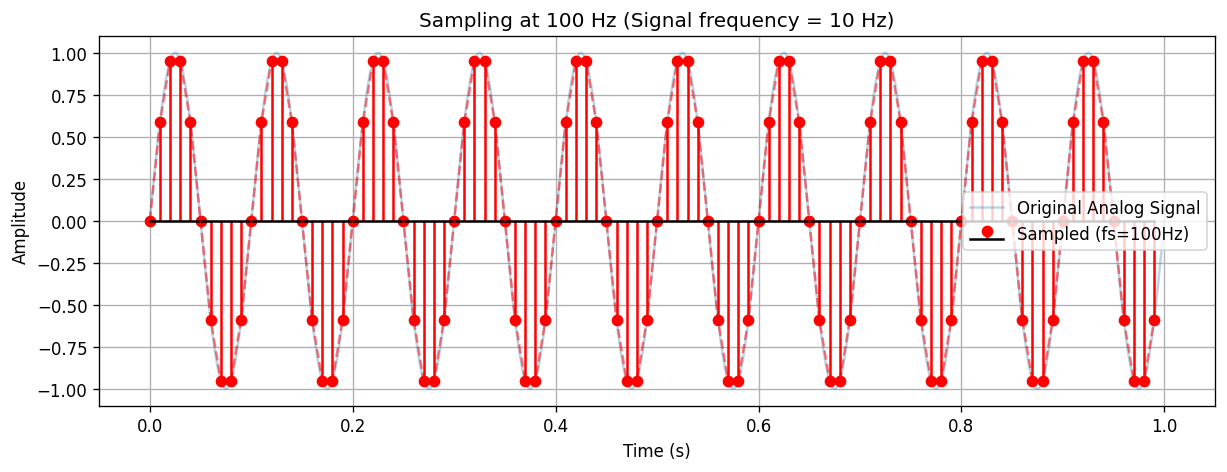

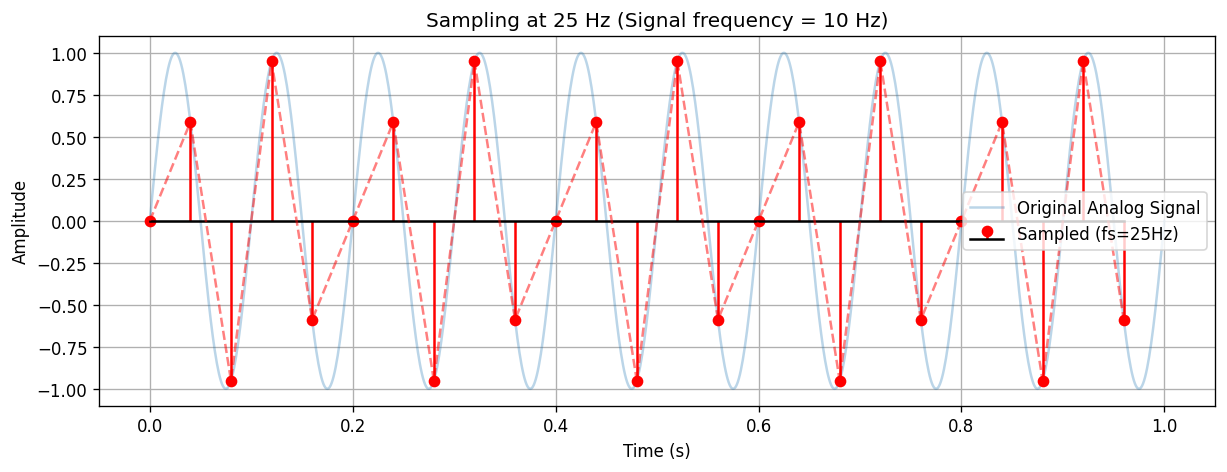

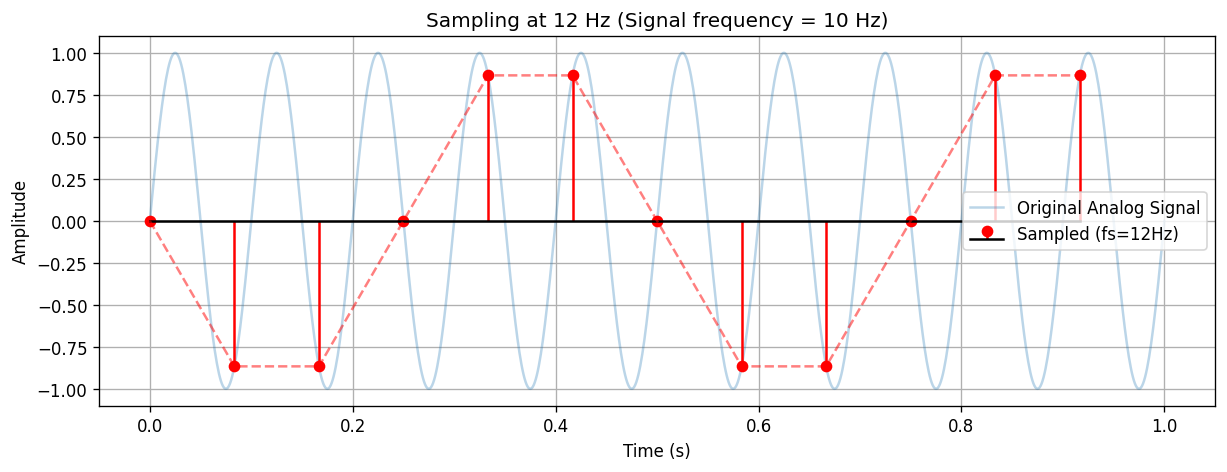

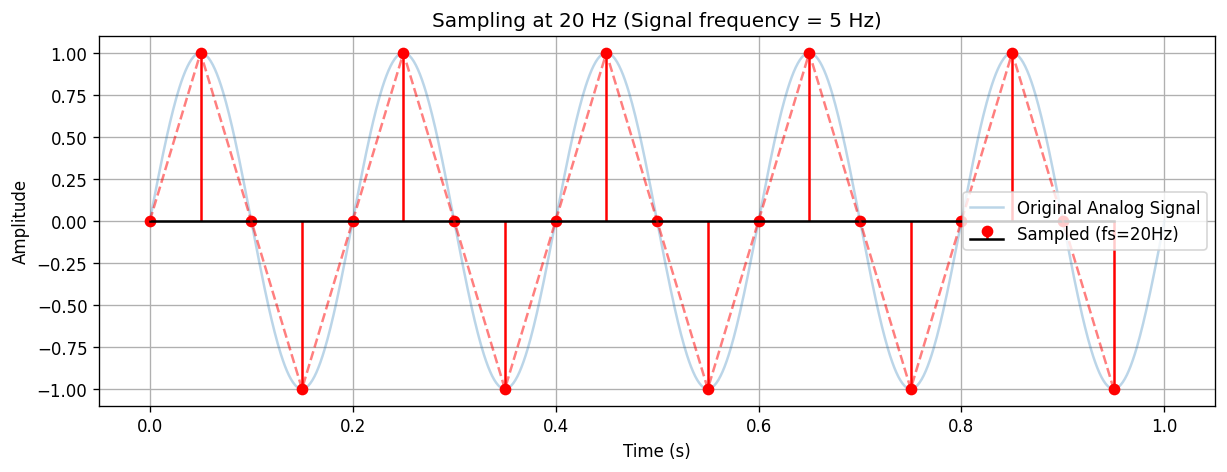

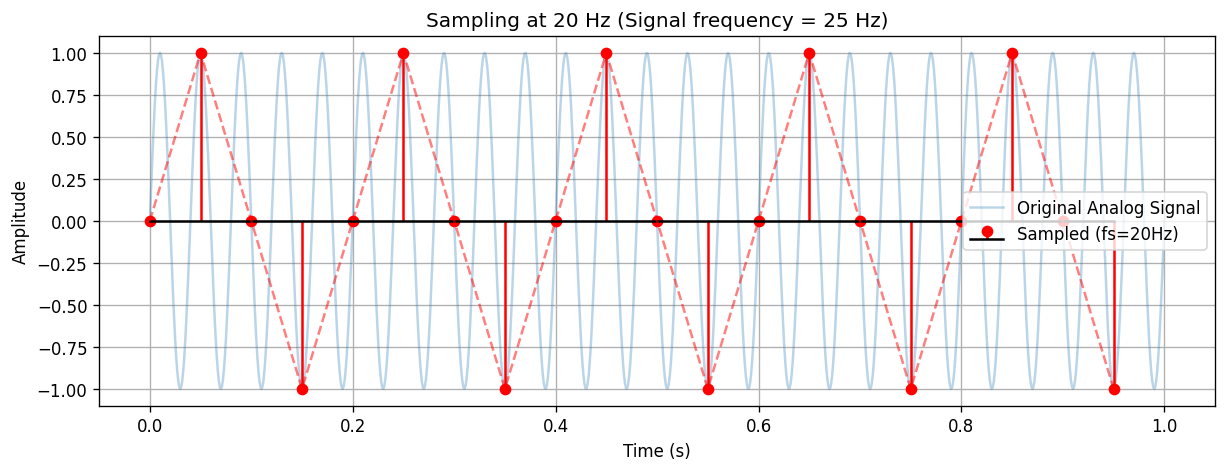

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def plot_sampling(f_signal, fs):
    # 1. 模拟“连续”原始信号
    t_continuous = np.linspace(0, 1, 1000)
    y_continuous = np.sin(2 * np.pi * f_signal * t_continuous)

    # 2. 进行采样
    t_sampled = np.arange(0, 1, 1/fs)
    y_sampled = np.sin(2 * np.pi * f_signal * t_sampled)

    # 3. 绘图
    plt.figure(figsize=(12, 4))
    plt.plot(t_continuous, y_continuous, label='Original Analog Signal', alpha=0.3)
    plt.stem(t_sampled, y_sampled, linefmt='r-', markerfmt='ro', basefmt='k-',
             label=f'Sampled (fs={fs}Hz)')
    plt.plot(t_sampled, y_sampled, 'r--', alpha=0.5)

    plt.title(f"Sampling at {fs} Hz (Signal frequency = {f_signal} Hz)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

# =========================
# A任务
# =========================
plot_sampling(10, 100)   # 良好还原
plot_sampling(10, 25)    # 勉强还原
plot_sampling(10, 12)    # 不满足奈奎斯特，发生混叠

# =========================
# B任务
# 固定采样率 fs=20Hz
# 比较 5Hz 和 25Hz
# =========================
plot_sampling(5, 20)     # 正常采样
plot_sampling(25, 20)    # 发生混叠，看起来像 5Hz